# CSE636 Week 4 lab — time-series forecasting for autoscaling

**Chi Zhang** · dataset: **Alibaba cluster-trace-v2018** (real), with the handout's
synthetic series kept as a control.

Every number and figure below is produced by running this notebook. The helper
modules it imports live in [`../scripts/`](../scripts) and are the same ones the
report uses, so the notebook and the report cannot drift apart.

| step | what it does |
|---|---|
| 0 | environment |
| 1 | the dataset — and why the handout's download link does not work |
| 2 | explore: daily cycle, spikes, gaps |
| 3 | train Prophet (with the seasonality choice made on a validation day) |
| 4 | evaluate: MAE / MAPE / interval coverage on the held-out 24 h |
| 5 | forecast → replica recommendation |
| 6 | the evaluation an autoscaler actually needs: 30 minutes ahead, vs 5 baselines |
| 7 | stretch: emit the forecast as a Prometheus metric for KEDA |

## Step 0 — environment

In [1]:
import sys, logging, warnings
sys.path.insert(0, "../scripts")
warnings.filterwarnings("ignore")
# Prophet logs one INFO line per chain per fit and this notebook fits ~110 times.
for noisy in ("cmdstanpy", "prophet"):
    logging.getLogger(noisy).setLevel(logging.CRITICAL)

import numpy as np, pandas as pd, matplotlib.pyplot as plt, prophet, sklearn, statsmodels
print("python     ", sys.version.split()[0])
for m in (np, pd, prophet, sklearn, statsmodels):
    print(f"{m.__name__:12s}", m.__version__)
%matplotlib inline

python      3.10.11
numpy        2.2.6
pandas       2.3.3
prophet      1.3.0
sklearn      1.7.2
statsmodels  0.14.6


## Step 1 — the dataset

The handout offers the Alibaba 2018 cluster trace at

```
https://github.com/alibaba/clusterdata/raw/master/cluster-trace-v2018/machine_usage.csv
```

That URL returns **404** — the CSV is not in the git repository. The trace's own
`fetchData.sh` points at an OSS bucket where `machine_usage` is a **1.77 GB
tarball** holding a **9.0 GB** CSV (≈246 M rows, 4 034 machines × 8 days).

Rows are grouped by machine, so `../scripts/fetch_alibaba.py` streams the
tarball, keeps the first 24 machine ids it meets and hangs up — **2 MB of
transfer instead of 1.77 GB**. `../scripts/prepare_data.py` then resamples each
machine onto a 5-minute grid and averages the 22 serving machines, because an
HPA reads the *average* utilisation across pods, not a single one.

In [2]:
from dataio import load, as_prophet, split
df = load("alibaba")
print(df.head(3).to_string(index=False))
print(f"\n{len(df)} five-minute buckets, "
      f"{(df.ds.max()-df.ds.min()).total_seconds()/86400:.2f} days, "
      f"{df.cpu.isna().sum()} with no reading")

                 ds       cpu    memory  machines_reporting
2018-01-01 00:00:00 16.539683 89.000000                  12
2018-01-01 00:05:00 28.883333 91.741667                  10
2018-01-01 00:10:00 27.925000 90.351667                  10

2304 five-minute buckets, 8.00 days, 64 with no reading


## Step 2 — explore and preprocess

In [3]:
from explore import describe, plot, SCALE_UP_THRESHOLD
stats = describe(df, "alibaba")

== alibaba ==
           cpu   memory
count  2240.00  2240.00
mean     40.39    90.20
std      10.08     2.84
min      16.54    79.29
25%      32.58    88.46
50%      39.18    90.59
75%      46.66    92.39
max      82.66    95.85

rows          : 2304   span: 8.00 days   step: 5 min
missing cpu   : 64 (2.8% of buckets)
gaps          :
  2018-01-02 15:10:00 -> 2018-01-02 15:10:00  (1 buckets, 0.1 h)
  2018-01-02 15:20:00 -> 2018-01-02 20:30:00  (63 buckets, 5.2 h)
autocorrelation: 1 h=+0.655, 12 h=-0.457, 24 h=+0.684, 7 d=+0.523
busiest hour-of-day: 6:00 at 61.4% CPU; quietest: 23:00 at 29.9%
peak 5-min bucket  : 82.7% at 2018-01-08 05:55:00
minutes above 70%: 85 of 11520



wrote ../figures/metrics_overview.png


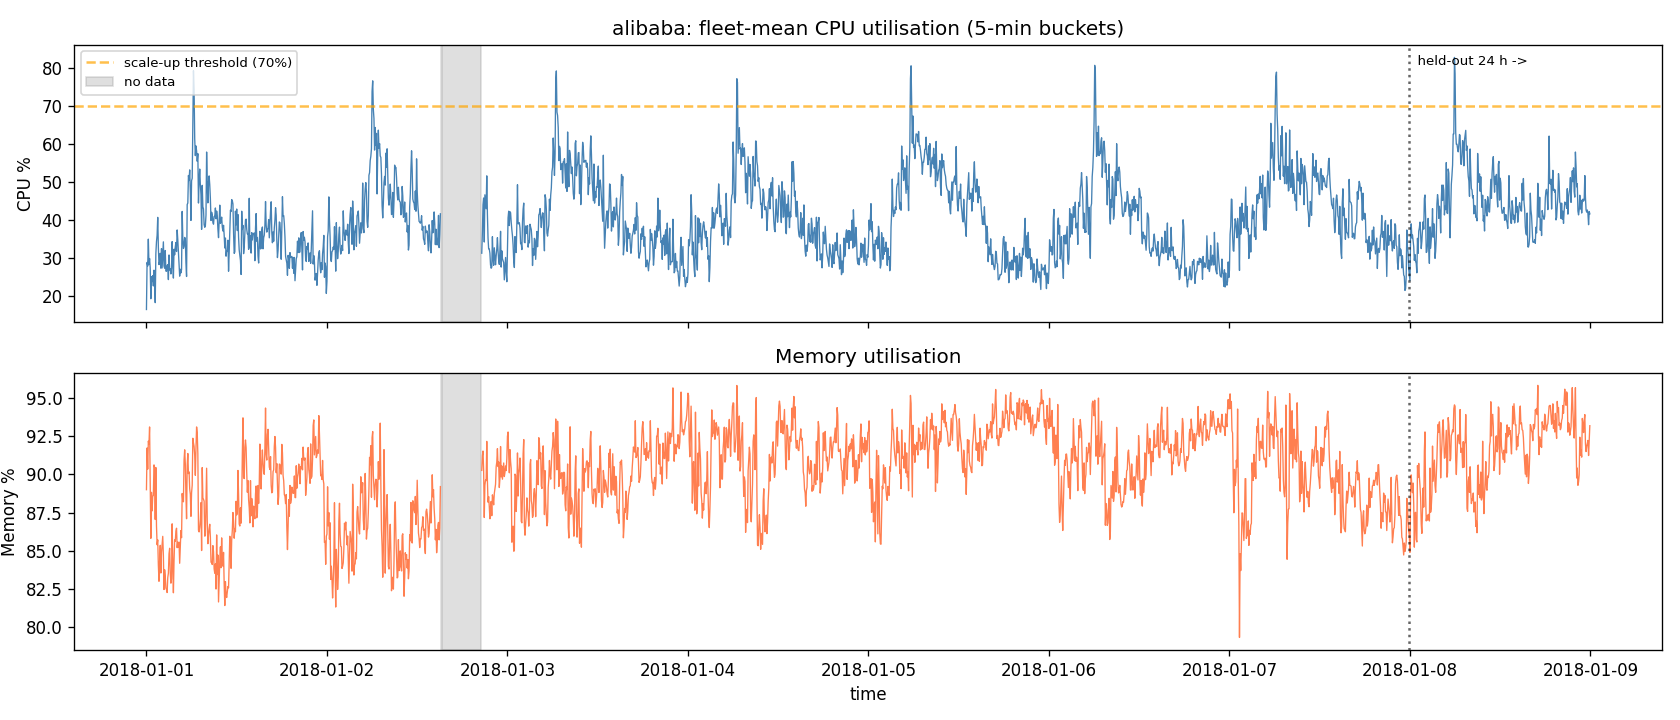

In [4]:
plot(df, "alibaba", "../figures/metrics_overview.png")
from IPython.display import Image
Image("../figures/metrics_overview.png")

Three things the handout asks us to look for, and what is actually there:

* **repeating daily peaks** — yes: autocorrelation at the 24-hour lag is
  **+0.68**, and the busiest hour of the day averages ~61% CPU against ~30% at
  the quietest. The shape is a sharp morning ramp, not a smooth sine.
* **sudden spikes** — yes: single 5-minute buckets reach **82.7%** while the
  surrounding hour sits near 50%.
* **gaps** — yes, and a big one: **5.2 hours on 2018-01-02** where not one of
  the 22 machines reported. It is shaded grey above. This matters for model
  choice later: Prophet regresses on time and simply has no observations there,
  whereas an ARIMA needs a regularly spaced series and would have to be handed
  interpolated values it would then treat as real.

Note the memory panel: it sits at ~90% and barely cycles. On these machines
memory is **not** a useful autoscaling signal — it is nearly saturated and does
not track demand. CPU is the metric to scale on.

## Step 3 — train the Prophet model

Temporal split, never shuffled: the last 24 hours are held out.

The one hyper-parameter worth arguing about is weekly seasonality. Eight days
of data contains **one** weekly cycle, so "add a weekly term" is a claim to be
checked rather than a default. It is chosen on a **validation day carved out of
the training data** — choosing it on the test day would make the reported MAPE
the better of two tries instead of an honest forecast.

In [5]:
from forecast_model import fit, score
from sklearn.metrics import mean_absolute_error

series = as_prophet(df)
train, test = split(series)
print(f"train {len(train)} points  {train.ds.min()} .. {train.ds.max()}")
print(f"test  {len(test)} points  {test.ds.min()} .. {test.ds.max()}")

sub_train, valid = split(train)
val = {}
for weekly in (False, True):
    mv = fit(sub_train, weekly)
    val[weekly] = mean_absolute_error(valid.y, mv.predict(valid[["ds"]]).yhat)
print(f"\nvalidation-day MAE: weekly_off={val[False]:.2f}  weekly_on={val[True]:.2f}")
WEEKLY = val[True] < val[False]
print("chosen: weekly_seasonality =", WEEKLY)

01:06:15 - cmdstanpy - INFO - Chain [1] start processing


train 1951 points  2018-01-01 00:00:00 .. 2018-01-07 23:50:00
test  289 points  2018-01-07 23:55:00 .. 2018-01-08 23:55:00


01:06:15 - cmdstanpy - INFO - Chain [1] done processing


01:06:16 - cmdstanpy - INFO - Chain [1] start processing


01:06:16 - cmdstanpy - INFO - Chain [1] done processing



validation-day MAE: weekly_off=10.21  weekly_on=5.95
chosen: weekly_seasonality = True


In [6]:
model = fit(train, WEEKLY)
future = model.make_future_dataframe(periods=len(test) + 6, freq="5min")
forecast = model.predict(future)
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(3)

01:06:16 - cmdstanpy - INFO - Chain [1] start processing


01:06:16 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
2243,2018-01-09 00:15:00,41.895944,34.086068,48.668917
2244,2018-01-09 00:20:00,42.020040,34.415239,49.776656
2245,2018-01-09 00:25:00,42.141228,35.138663,49.578236


wrote ../figures/cpu_forecast.png


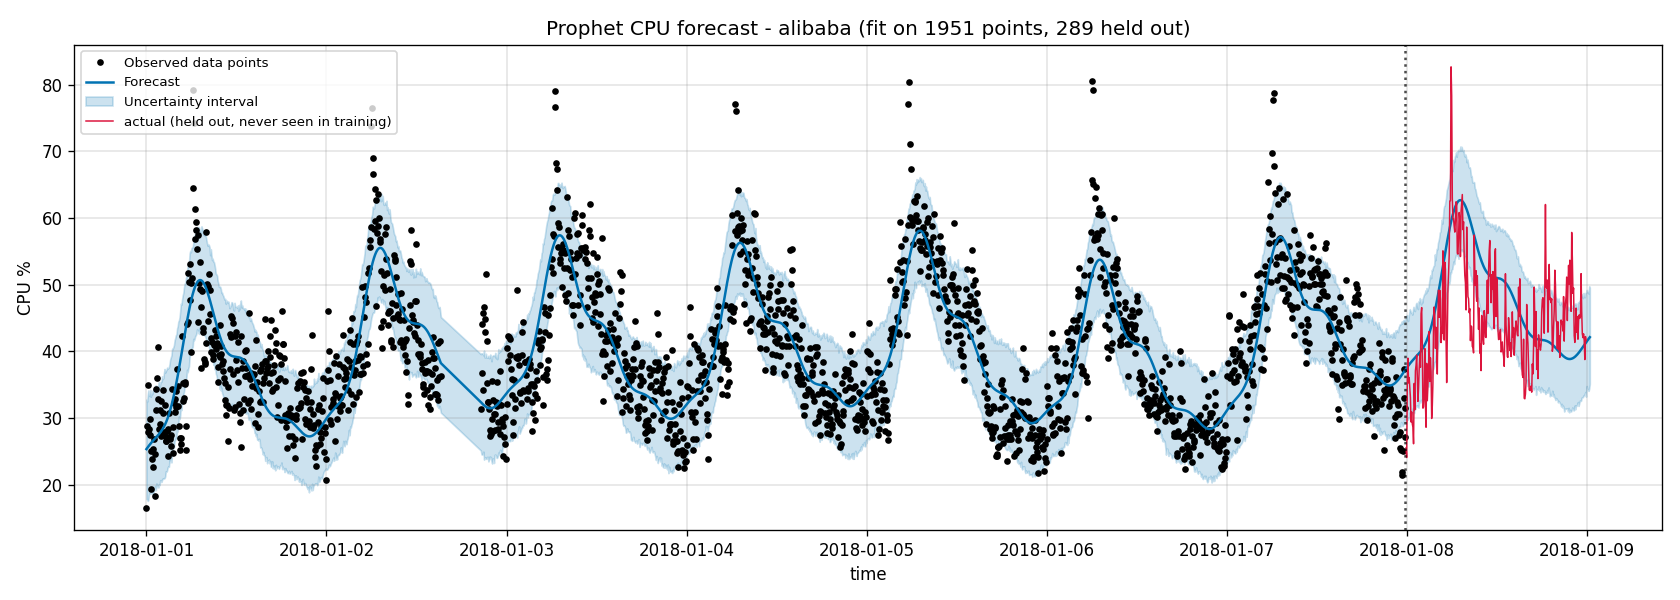

In [7]:
from forecast_model import plot_forecast, plot_components
plot_forecast(model, forecast, train, test, "alibaba", "../figures/cpu_forecast.png")
Image("../figures/cpu_forecast.png")

wrote ../figures/cpu_forecast_components.png


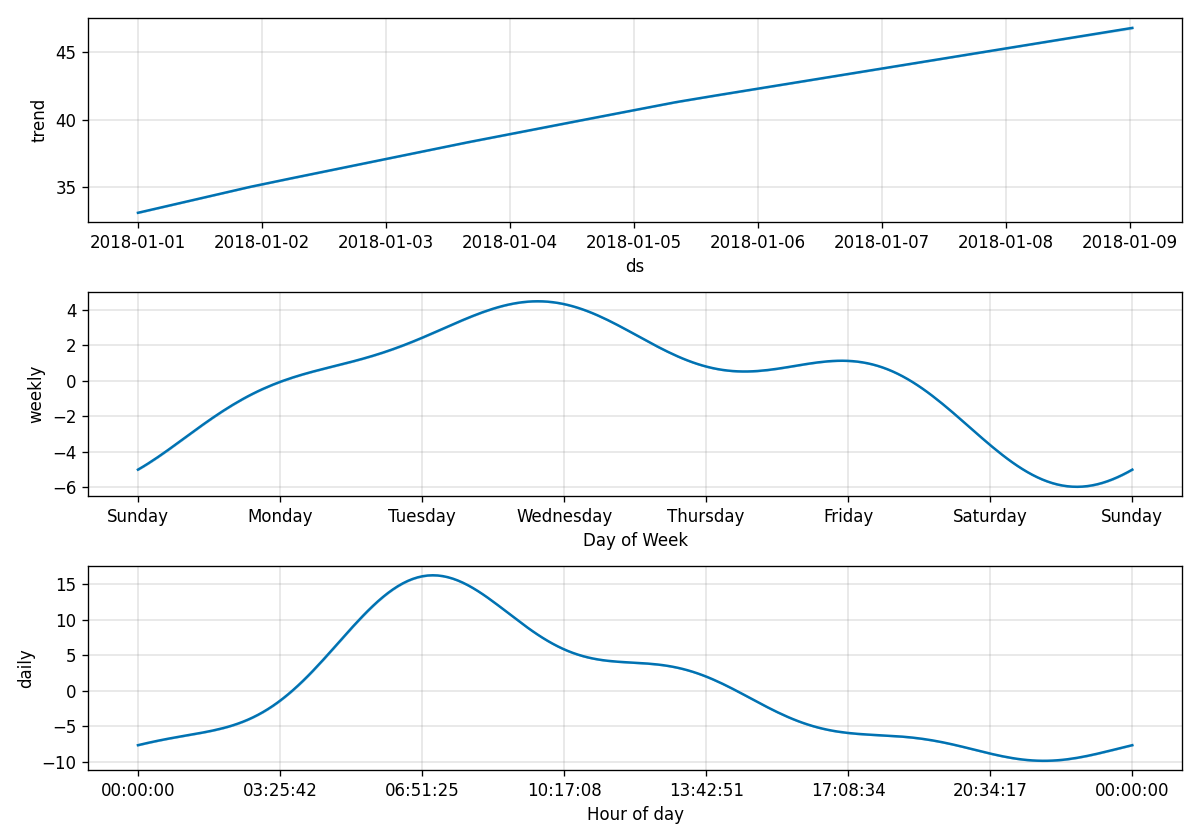

In [8]:
plot_components(model, forecast, "../figures/cpu_forecast_components.png")
Image("../figures/cpu_forecast_components.png")

## Step 4 — evaluate on the held-out 24 hours

Beyond MAE and MAPE this reports **interval coverage**: the share of held-out
points that landed inside the nominal 80% interval. The scaling rule uses
`yhat_upper` as its safety margin, so if that interval is too narrow the margin
is not the margin it claims to be.

In [9]:
tf = forecast[forecast.ds.isin(test.ds)].reset_index(drop=True)
metrics = score(test.y.to_numpy(), tf.yhat.to_numpy(),
                tf.yhat_lower.to_numpy(), tf.yhat_upper.to_numpy())
for k, v in metrics.items():
    print(f"{k:24s} {v:8.3f}" if isinstance(v, float) else f"{k:24s} {v}")

n                        289
mae                         6.333
mape                       14.979
rmse                        7.809
bias                        2.505
under_forecast_pct         34.602
interval_coverage_pct      63.668
mean_interval_width        15.208
above_upper_pct             8.304


wrote ../figures/cpu_eval.png


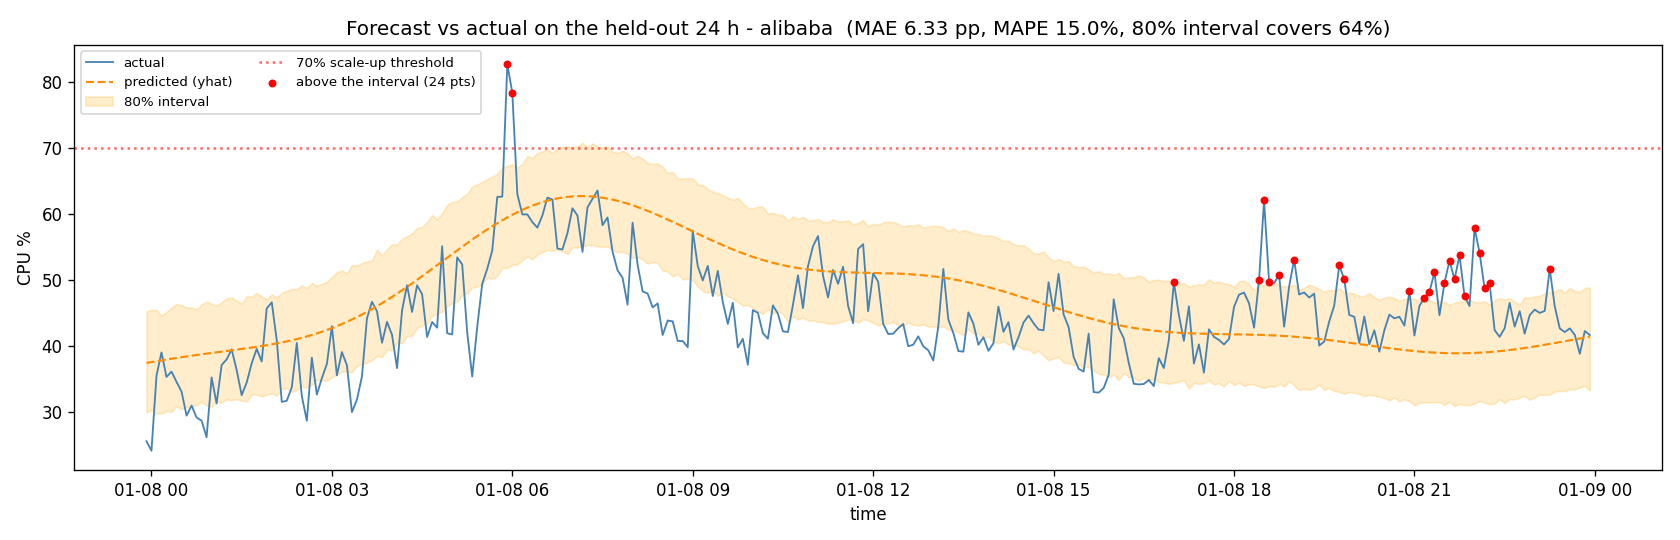

In [10]:
from forecast_model import plot_eval
plot_eval(test, tf, metrics, "alibaba", "../figures/cpu_eval.png")
Image("../figures/cpu_eval.png")

## Step 5 — forecast → scaling decision

`scaling.recommend()` is the lab's arithmetic —
`ceil(replicas × predicted / target)`, clamped — plus a **reactive floor**: the
recommendation is the larger of what the forecast asks for and what the current
reading already asks for. The floor is silent whenever the forecast is leading
correctly, and it is the only thing standing between an unforecast spike and a
saturated service.

In [11]:
from scaling import recommend
horizon = forecast.tail(6)                 # next 30 minutes, 5-minute steps
max_pred = float(horizon.yhat_upper.max())
observed = float(test.y.iloc[-1])
d = recommend(20, max_pred, observed_cpu=observed, target_cpu_per_replica=60)

print(f"Current replicas:            {d.current_replicas}")
print(f"Max predicted CPU (30 min):  {max_pred:.1f}%  (upper 80% bound)")
print(f"Last observed CPU:           {observed:.1f}%")
print(f"Target CPU per replica:      60%")
print(f"Recommended replicas:        {d.recommended_replicas}   (driver: {d.driver})")
print(f"DECISION: {d.action}")

Current replicas:            20
Max predicted CPU (30 min):  49.8%  (upper 80% bound)
Last observed CPU:           41.6%
Target CPU per replica:      60%
Recommended replicas:        17   (driver: forecast)
DECISION: Scale DOWN by 3 replica(s)


## Step 6 — the evaluation an autoscaler actually needs

Step 4 fits once and forecasts 24 hours. No autoscaler works that way: it
re-decides every few minutes with all the history up to *now*, and looks only
30 minutes ahead. Below, every origin on the test day retrains and forecasts
the next 30 minutes, and four cheap baselines are scored on exactly the same
points — so "Prophet is better" has to survive being measured.

In [12]:
%run ../scripts/rolling_eval.py --dataset alibaba

alibaba: 49 origins, horizon 30 min (6 steps of 5 min)


01:06:17 - cmdstanpy - INFO - Chain [1] start processing


01:06:17 - cmdstanpy - INFO - Chain [1] done processing


01:06:17 - cmdstanpy - INFO - Chain [1] start processing


01:06:17 - cmdstanpy - INFO - Chain [1] done processing


...

01:06:32 - cmdstanpy - INFO - Chain [1] done processing


C:\cv4\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


01:06:32 - cmdstanpy - INFO - Chain [1] start processing


01:06:32 - cmdstanpy - INFO - Chain [1] done processing


  48/49 origins, 16s

scored 1728 (origin, method, step) points in 16s

method                MAE (pp)   MAPE %    RMSE    bias
arima_212                 4.64     10.4    6.06   -0.76
prophet_level_adj         4.90     11.1    6.16   -0.31
moving_avg_30m            4.92     11.1    6.32   -0.24
persistence               5.41     12.0    7.39   -0.94
prophet                   5.70     12.7    7.32   -2.11
seasonal_naive_24h        7.31     16.3    9.42   -1.74

Prophet MAE by horizon (min): 5m=6.16, 10m=5.85, 15m=4.92, 20m=6.28, 25m=5.16, 30m=5.80

Decision-level: does the upper bound cover the actual 30-min peak?
  prophet yhat_upper                      60% of 48 decisions   mean shortfall 7.1 pp   worst 22.3 pp
  level-adjusted upper                    69% of 48 decisions   mean shortfall 5.0 pp   worst 27.1 pp
  reactive floor (max of upper, now)      71% of 48 decisions   mean shortfall 4.9 pp   worst 27.1 pp
  the day's peak: actual 82.7% vs prophet upper 60.3% at origin 2018-01-0

The ranking is the most useful thing this lab produced. **At a 30-minute horizon
on real data, plain Prophet loses to a 30-minute moving average and to
persistence.** The reason is structural: Prophet has no autoregressive term —
`yhat(t)` is a function of the clock, not of what the metric is doing right
now — so when the fleet sits above its seasonal curve for an hour, Prophet keeps
predicting the curve. Adding the mean residual of the last 30 minutes
(`prophet_level_adj`) recovers most of the gap.

Running the same comparison on the handout's synthetic series flips the ranking
completely — Prophet wins there, because that series *is* a sum of sines plus
Gaussian noise, which is Prophet's own model class. A method evaluated only on
that data would look far better than it is.

In [13]:
%run ../scripts/rolling_eval.py --dataset synthetic

01:06:33 - cmdstanpy - INFO - Chain [1] start processing


synthetic: 49 origins, horizon 30 min (6 steps of 5 min)


01:06:33 - cmdstanpy - INFO - Chain [1] done processing


01:06:33 - cmdstanpy - INFO - Chain [1] start processing


01:06:33 - cmdstanpy - INFO - Chain [1] done processing


...

01:06:46 - cmdstanpy - INFO - Chain [1] start processing


01:06:46 - cmdstanpy - INFO - Chain [1] done processing


01:06:46 - cmdstanpy - INFO - Chain [1] start processing


01:06:46 - cmdstanpy - INFO - Chain [1] done processing


  48/49 origins, 14s

scored 1728 (origin, method, step) points in 14s

method                MAE (pp)   MAPE %    RMSE    bias
prophet                   2.34      8.1    2.97   +0.20
prophet_level_adj         2.46      8.4    3.09   +0.07
arima_212                 2.78      9.5    3.50   -0.26
moving_avg_30m            2.89      9.8    3.62   -0.14
persistence               3.00      9.9    3.70   -0.35
seasonal_naive_24h        6.74     22.6    7.76   -6.33

Prophet MAE by horizon (min): 5m=2.71, 10m=2.31, 15m=2.36, 20m=2.53, 25m=2.28, 30m=1.87

Decision-level: does the upper bound cover the actual 30-min peak?
  prophet yhat_upper                      73% of 48 decisions   mean shortfall 1.6 pp   worst 4.6 pp
  level-adjusted upper                    69% of 48 decisions   mean shortfall 1.9 pp   worst 5.5 pp
  reactive floor (max of upper, now)      69% of 48 decisions   mean shortfall 1.9 pp   worst 5.5 pp
  the day's peak: actual 58.5% vs prophet upper 56.8% at origin 2025-10-07 0

### How repeatable is the number we act on?

`yhat` is a deterministic MAP fit, but `yhat_upper` is estimated from 1000
Monte-Carlo trajectories that nothing seeds. Twelve identical runs:

In [14]:
%run ../scripts/reproducibility.py --runs 12

01:06:46 - cmdstanpy - INFO - Chain [1] start processing


01:06:46 - cmdstanpy - INFO - Chain [1] done processing


01:06:47 - cmdstanpy - INFO - Chain [1] start processing


01:06:47 - cmdstanpy - INFO - Chain [1] done processing


  run  1: yhat_max 42.938  yhat_upper_max 51.515  -> 18 replicas


...

  run 10: yhat_max 42.938  yhat_upper_max 51.048  -> 18 replicas


01:06:49 - cmdstanpy - INFO - Chain [1] start processing


01:06:49 - cmdstanpy - INFO - Chain [1] done processing


  run 11: yhat_max 42.938  yhat_upper_max 50.617  -> 17 replicas


  run 12: yhat_max 42.938  yhat_upper_max 51.144  -> 18 replicas

yhat_max       : 42.938 +/- 0.000 (spread 0.000 pp)
yhat_upper_max : 51.003 +/- 0.337 (spread 1.109 pp)
replica recommendation across 12 identical runs: [17, 18]
wrote C:\Users\zhang\OneDrive\Desktop\cse636-week04\results\reproducibility.json


The point forecast is bit-identical across all twelve runs; the upper bound
moves by up to **0.66 points**, and that is enough to flip the recommendation
between **17 and 18 replicas**. An autoscaler wired straight to this would start
and stop a pod because of Monte-Carlo noise. Fixes: raise `uncertainty_samples`,
seed the draw, or quantise the recommendation (only act on a change of ≥2
replicas) — the third is the one that survives contact with production.

## Step 7 (stretch) — emit the forecast as a Prometheus metric

`../scripts/exporter.py` serves `predicted_cpu_next_30m` on `:8000/metrics`,
and `../k8s/keda-scaledobject.yaml` is the KEDA `ScaledObject` that scales on
it. The exporter is started here for a few seconds and its own `/metrics`
endpoint is scraped, so the output below is the real exposition format.

In [15]:
%run ../scripts/exporter.py --once --port 8009

01:06:49 - cmdstanpy - INFO - Chain [1] start processing


serving /metrics on :8009


01:06:49 - cmdstanpy - INFO - Chain [1] done processing


predicted_cpu_next_30m = 51.5%   observed = 41.6%   (fit took 0.2s)

--- scraped from our own /metrics ---
predicted_cpu_next_30m{service="checkout-api"} 51.46082410160131
observed_cpu_current{service="checkout-api"} 41.62373737373738
forecast_model_age_seconds{service="checkout-api"} 0.0


---

## Where this leaves the lab's three questions

Answered in full in [`../lab_notes.md`](../lab_notes.md); in one line each:

1. **MAPE 15.0% over 24 hours, 12.7% at the 30-minute horizon** — good enough to
   *size* a fleet, not good enough to be trusted alone, because the 80% interval
   covers only ~63% of reality and misses the day's peak by 21 points.
2. **The components plot** shows a ~26-point daily swing peaking at 07:00, a
   trend Prophet bends upward by +17 points across the window (an extrapolation
   risk, not an observation), and a weekly term that eight days cannot identify.
3. **An unforecast 95% spike** would be met by the reactive floor, not the
   forecast — which is why the floor exists, and why the simulation shows pure
   predictive autoscaling dropping 4× more load than plain HPA during a flash
   crowd.